## Why Poisson Arrivals Make the SNC Latency Bound Loose

In `method_v2`, the PPG is several times the measured p95 latency with Poisson arrivals, but close to it with
periodic arrivals (see the tables there). This notebook explains where that gap comes from, one step at a time.

To isolate the effect, everything here uses **one service** (s1 of `method_v2`) with its **true** parameters: no GP,
no epistemic uncertainty, no composition. The execution time $X$ of an item is Gaussian, and only the arrival
process changes between the two cases:

- **Poisson:** gaps between arrivals are exponential with mean $1/\lambda$.
- **Periodic:** gaps are $1/\lambda$ plus or minus a small uniform jitter.

The parameter values are set in the first code cell and printed below it.

The sections follow the chain of reasoning:

1. The two arrival processes: same rate, very different gaps
2. What the queue looks like over time
3. The true latency distribution
4. How the SNC bound is built, and which of its steps costs how much
5. The core reason: how large $\theta$ may be
6. What the bound pays for, term by term
7. How the looseness depends on $\varepsilon$ and on the load
8. Why it gets worse along a chain

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

mu, sigma = 0.080, 0.006      # mean and std of the execution time of s1 (s)
arrival_rate = 8.0            # lambda (items/s)
jitter = 0.1                  # relative half-width of the uniform jitter on periodic gaps
epsilon = 0.05                # violation probability (p95)

theta_grid = np.logspace(-1, 5, 4000)   # MGF parameter theta (1/s), same grid as method_v2
processes = ["poisson", "periodic"]
colors = {"poisson": "tab:red", "periodic": "tab:blue"}


def sample_gaps(process, shape, rng, rate=arrival_rate):
    if process == "poisson":
        return rng.exponential(1.0 / rate, shape)
    return (1.0 / rate) * (1 + rng.uniform(-jitter, jitter, shape))


def log_gap_mgf(process, rate=arrival_rate):
    # ln E[exp(-theta T)] of one gap T
    if process == "poisson":
        return np.log(rate / (rate + theta_grid))
    shortest, width = (1 - jitter) / rate, 2 * jitter / rate
    return -theta_grid * shortest + np.log(-np.expm1(-theta_grid * width)) - np.log(theta_grid * width)


def log_mgf_execution():
    # ln M_X(theta) = theta mu + theta^2 sigma^2 / 2
    return theta_grid * mu + 0.5 * theta_grid ** 2 * sigma ** 2


def simulate_latency(process, n_items, rng, rate=arrival_rate, warmup=1000):
    # Lindley recursion for one FIFO server: wait_i = max(0, wait_{i-1} + X_{i-1} - T_i)
    gaps = sample_gaps(process, n_items, rng, rate)
    execution = np.maximum(rng.normal(mu, sigma, n_items), 0.0)
    wait = np.zeros(n_items)
    for i in range(1, n_items):
        wait[i] = max(0.0, wait[i - 1] + execution[i - 1] - gaps[i])
    return (wait + execution)[warmup:], wait[warmup:]


ms = lambda seconds: f"{seconds * 1000:.0f} ms"


def span(values, fmt):
    # "between a and b", or just "a" if both round to the same text
    low, high = fmt(np.min(values)), fmt(np.max(values))
    return low if low == high else f"between {low} and {high}"

display(Markdown(
    rf"**Setup.** Execution time $X \sim \mathcal{{N}}(\mu, \sigma^2)$ with $\mu$ = {ms(mu)}, $\sigma$ = {ms(sigma)}. "
    rf"Arrival rate $\lambda$ = {arrival_rate:g}/s, so the server is busy $\rho = \lambda\mu$ = {arrival_rate * mu:.0%} of the time. "
    rf"Poisson gaps: exponential with mean {ms(1 / arrival_rate)}. "
    rf"Periodic gaps: {ms(1 / arrival_rate)} ± up to {jitter:.0%}, i.e. between {ms((1 - jitter) / arrival_rate)} and {ms((1 + jitter) / arrival_rate)}. "
    rf"Target violation probability $\varepsilon$ = {epsilon:g}."))

**Setup.** Execution time $X \sim \mathcal{N}(\mu, \sigma^2)$ with $\mu$ = 80 ms, $\sigma$ = 6 ms. Arrival rate $\lambda$ = 8/s, so the server is busy $\rho = \lambda\mu$ = 64% of the time. Poisson gaps: exponential with mean 125 ms. Periodic gaps: 125 ms ± up to 10%, i.e. between 112 ms and 138 ms. Target violation probability $\varepsilon$ = 0.05.

## 1. Same Rate, Very Different Gaps

Both processes deliver the same number of items per second on average. The difference is in how the gaps are
spread. An item has to wait whenever it arrives while the previous item is still being served, i.e. when its gap is
shorter than about one execution time (dashed line).

The exponential distribution has its **highest density at zero**: short gaps are the most likely ones. Periodic gaps
stay close to $1/\lambda$. The legend shows the share of gaps shorter than the mean execution time for each process.

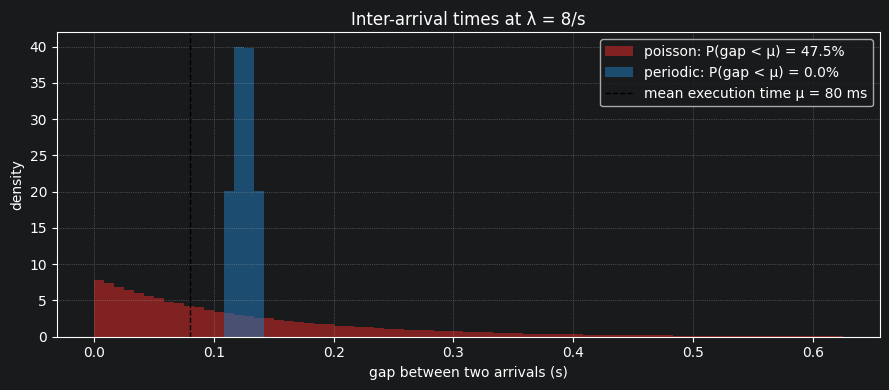

In [23]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 5 / arrival_rate, 76)
for process in processes:
    gaps = sample_gaps(process, 200_000, rng)
    ax.hist(gaps, bins=bins, density=True, alpha=0.55, color=colors[process],
            label=f"{process}: P(gap < μ) = {np.mean(gaps < mu):.1%}")
ax.axvline(mu, color="black", linestyle="--", linewidth=1, label=f"mean execution time μ = {ms(mu)}")
ax.set_xlabel("gap between two arrivals (s)")
ax.set_ylabel("density")
ax.set_title(f"Inter-arrival times at λ = {arrival_rate:g}/s")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 2. The Queue over Time

The plot shows the server's **backlog**: the work that has arrived but is not done yet (the rest of the item being
served plus everything waiting behind it), measured in seconds of execution time.

- When an item arrives, the backlog **jumps up by that item's execution time $X$**, because the item brings $X$
  seconds of work.
- While the server is busy, the backlog **drains at slope $-1$**: the server does one second of work per second of
  real time, so the line falls by 1 s per s (a 45° line down to zero, where the server goes idle).
- The height of the backlog **just before** an item arrives is exactly how long that item waits.

With periodic arrivals, every triangle drains to zero before the next item arrives, so no item waits. With Poisson
arrivals, items **bunch up**: several arrive shortly after each other, and the later ones stack on top of the
earlier ones' triangles and wait. The server is still idle most of the time (Section 3 prints the share of items
that wait), so the average wait is small. But the p95 latency is decided by these bursts.

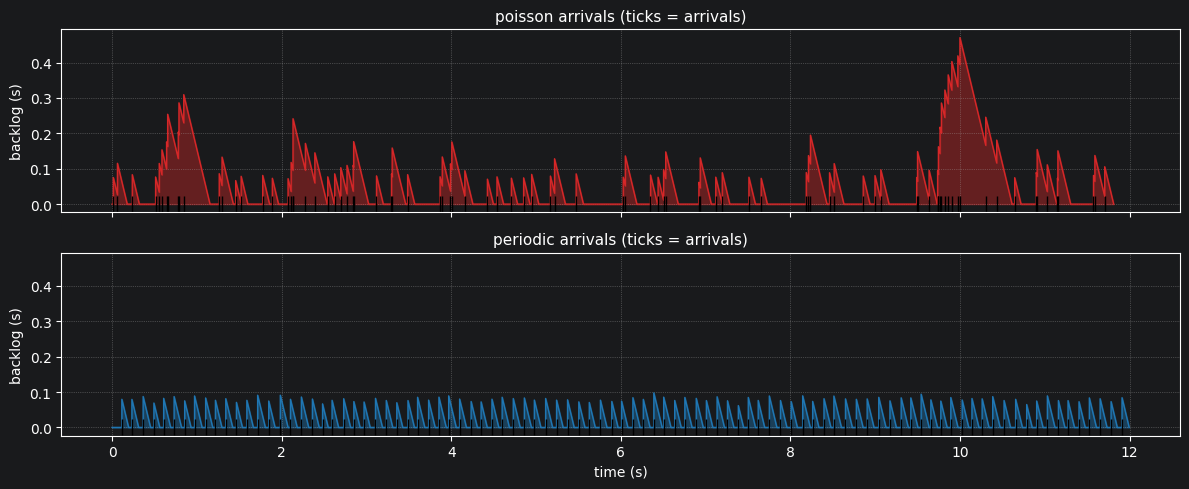

In [24]:
def backlog_path(arrivals, execution):
    # piecewise-linear backlog: jump by X at each arrival, drain at slope -1 down to 0
    times, levels, level, t = [0.0], [0.0], 0.0, 0.0
    for a, x in zip(arrivals, execution):
        drained = max(0.0, level - (a - t))
        if level > 0 and drained == 0.0:
            times.append(t + level); levels.append(0.0)
        times += [a, a]; levels += [drained, drained + x]
        level, t = drained + x, a
    times.append(t + level); levels.append(0.0)
    return np.array(times), np.array(levels)


horizon = 12.0   # seconds of simulated time to show
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, sharey=True)
for ax, process in zip(axes, processes):
    rng = np.random.default_rng(3)
    arrivals = np.cumsum(sample_gaps(process, int(3 * horizon * arrival_rate), rng))
    arrivals = arrivals[arrivals < horizon]
    execution = rng.normal(mu, sigma, len(arrivals))
    times, levels = backlog_path(arrivals, execution)
    ax.fill_between(times, levels, color=colors[process], alpha=0.4)
    ax.plot(times, levels, color=colors[process], linewidth=1)
    ax.plot(arrivals, np.zeros_like(arrivals), "k|", markersize=12)
    ax.set_ylabel("backlog (s)")
    ax.set_title(f"{process} arrivals (ticks = arrivals)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## 3. The True Latency Distribution

The **latency** (sojourn time) $W_i$ of item $i$ is the time from its arrival until it leaves the service: its
wait plus its execution time. For a FIFO server it follows from the previous item's latency (Lindley's recursion):

$$W_i \;=\; \underbrace{\max\big(0,\; W_{i-1} - T_i\big)}_{\text{wait } Q_i} \;+\; X_i,$$

with, all in seconds,

- $X_i$: the execution time of item $i$,
- $T_i$: the gap between the arrivals of item $i-1$ and item $i$,
- $W_{i-1}$: the latency of the previous item.

For **Poisson** arrivals, the mean latency also has a closed form (Pollaczek–Khinchine):

$$\mathbb{E}[W] \;=\; \mu \;+\; \frac{\lambda\,\mathbb{E}[X^2]}{2(1-\rho)}, \qquad \mathbb{E}[X^2] = \mu^2 + \sigma^2, \quad \rho = \lambda\mu.$$

The second term is the mean wait. It is small at low load and grows without limit as $\rho \to 1$. The table below
compares it with the simulation. There is no such simple formula for the p95, which is one reason the tail needs a
bound. For **periodic** arrivals with gaps longer than any execution time, $W_{i-1} < T_i$ always holds, so
$W_i = X_i$.

The plot shows the *complementary CDF*
$P(\text{latency} > d)$ on a log scale, which is the natural view for tails: the p95 latency is where a curve
crosses the dashed line at $\varepsilon$.

- **Periodic:** nobody waits, so the latency is just the execution time. The tail is Gaussian and falls off a cliff
  just above $\mu$.
- **Poisson:** most items don't wait, so the curve first drops to the share of items that do. After that it falls
  along a **straight line**, i.e. the latency tail is **exponential**. The slope of that line is the tail's *decay
  rate*. Remember this slope; it's the key to everything below.

| process | share of items that wait | mean latency (simulated) | p95 latency (simulated) |
|---|---|---|---|
| poisson | 64.1% | 152 ms | 346 ms |
| periodic | 0.0% | 80 ms | 90 ms |

Pollaczek–Khinchine for Poisson: $\mathbb{E}[W]$ = 80 ms + 72 ms (mean wait) = 151.5 ms; simulated: 152.4 ms.

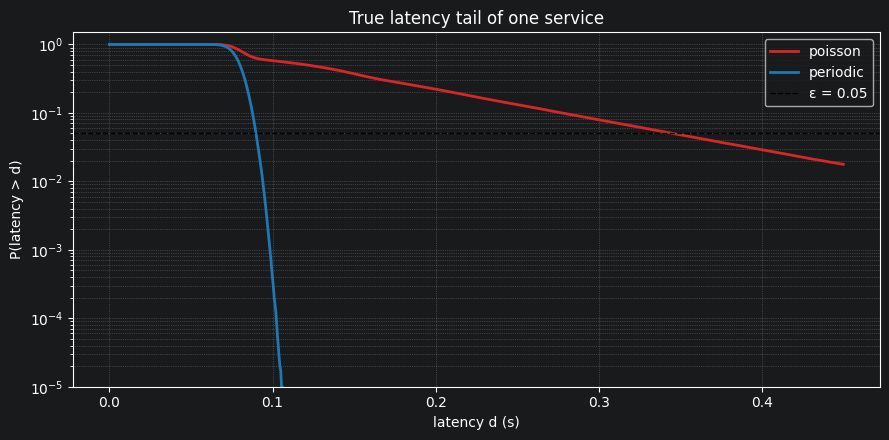

In [25]:
latency, wait_share = {}, {}
rows = []
for process in processes:
    latency[process], wait = simulate_latency(process, 400_000, np.random.default_rng(1))
    wait_share[process] = np.mean(wait > 0)
    rows.append(f"| {process} | {wait_share[process]:.1%} | {ms(latency[process].mean())} | {ms(np.quantile(latency[process], 1 - epsilon))} |")
display(Markdown("| process | share of items that wait | mean latency (simulated) | p95 latency (simulated) |\n|---|---|---|---|\n" + "\n".join(rows)))

rho = arrival_rate * mu
mean_pk = mu + arrival_rate * (mu ** 2 + sigma ** 2) / (2 * (1 - rho))
display(Markdown(f"Pollaczek–Khinchine for Poisson: $\\mathbb{{E}}[W]$ = {ms(mu)} + {ms(mean_pk - mu)} (mean wait) = {mean_pk * 1000:.1f} ms; "
                 f"simulated: {latency['poisson'].mean() * 1000:.1f} ms."))

d_axis = np.linspace(0, 0.45, 901)
fig, ax = plt.subplots(figsize=(9, 4.5))
for process in processes:
    ccdf = 1 - np.searchsorted(np.sort(latency[process]), d_axis, side="right") / len(latency[process])
    ax.semilogy(d_axis, np.where(ccdf > 0, ccdf, np.nan), color=colors[process], linewidth=2, label=process)
ax.axhline(epsilon, color="black", linestyle="--", linewidth=1, label=f"ε = {epsilon:g}")
ax.set_ylim(1e-5, 1.5)
ax.set_xlabel("latency d (s)")
ax.set_ylabel("P(latency > d)")
ax.set_title("True latency tail of one service")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. How the Bound Is Built, and What Each Step Costs

The latency $W$ of an item is the largest backlog it can find when looking back over the items before it:

$$W = \max_{n \ge 0} D_n, \qquad D_n = \underbrace{X_0 + \dots + X_n}_{\text{work of the item and the } n \text{ before it}} \;-\; \underbrace{(T_1 + \dots + T_n)}_{\text{time the server had to do it}}.$$

$D_n$ is the latency the item would have if the server had been busy continuously since $n$ items back. The SNC bound
replaces the true tail $P(W > d)$ by something computable in two steps:

1. **Union bound over $n$:** $P(\max_n D_n > d) \le \sum_n P(D_n > d)$. Loose when several $D_n$ tend to be large together.
2. **Chernoff bound on each term with a common $\theta$:** $P(D_n > d) \le e^{-\theta d}\,\mathbb{E}[e^{\theta D_n}] = e^{-\theta d}\,M_X(\theta)\,\rho(\theta)^n$
   with $\rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}]$. Summing the geometric series gives the bound from `method_v2`:
   $P(W > d) \le e^{-\theta d}\,M_X(\theta) / (1 - \rho(\theta))$, and the best $\theta$ is picked for every $d$.

Below, all three curves are computed for both processes: the truth, after step 1 (estimated by Monte Carlo), and after
step 2 (the SNC bound). The horizontal line at $\varepsilon$ cuts each curve at the p95 latency and at the two bounds
on it (black dots). The text below the plot says how far each step moves the p95.

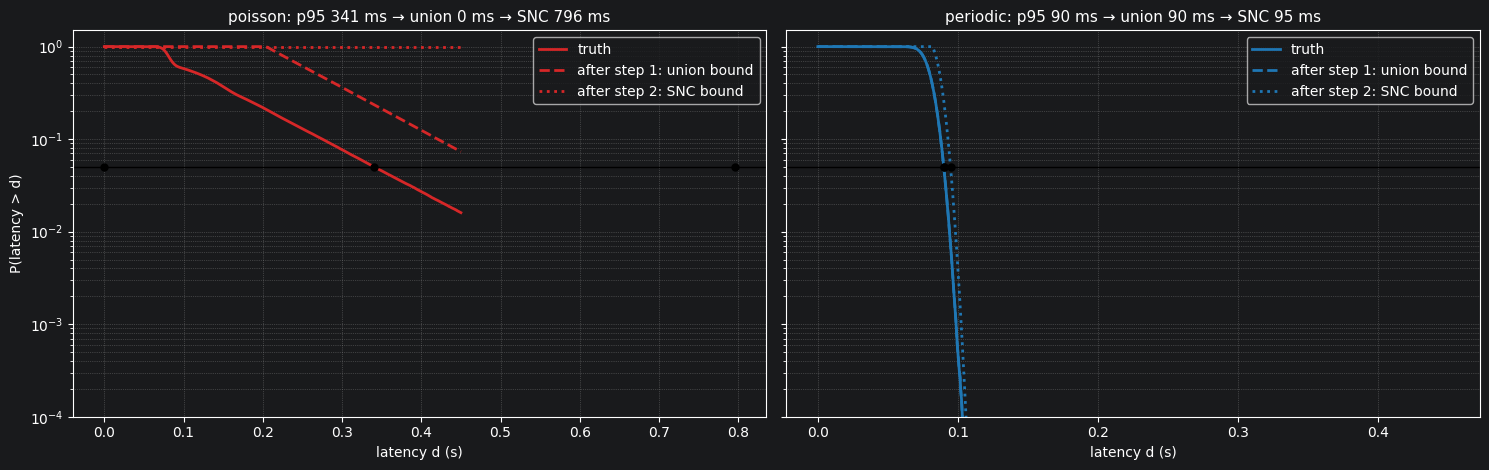

**What this shows.**
- **Step 1, union bound over $n$:** moves the p95 by -341 ms for Poisson (341 ms → 0 ms) and by 0 ms for periodic arrivals.
- **Step 2, Chernoff:** moves the Poisson bound on by another 796 ms to 796 ms, which is 2.33× the true p95. The periodic bound ends at 95 ms, 1.05× the true p95.
- On the log plot, the Poisson SNC bound (dotted) runs roughly *parallel* to the true tail, shifted to the right by 455 ms at $\varepsilon$.

In [26]:
n_paths, n_max = 200_000, 40   # Monte Carlo paths; largest queue length n considered


def log_latency_moment(process, rate=arrival_rate):
    # ln [ M_X(theta) / (1 - rho(theta)) ] on theta_grid; inf where rho(theta) >= 1
    log_mx = log_mgf_execution()
    log_rho = log_mx + log_gap_mgf(process, rate)
    moment = np.full_like(log_mx, np.inf)
    stable = log_rho < 0
    moment[stable] = log_mx[stable] - np.log1p(-np.exp(log_rho[stable]))
    return moment


def snc_bound(process, eps, rate=arrival_rate):
    values = (log_latency_moment(process, rate) - np.log(eps)) / theta_grid
    best = np.argmin(values)
    return values[best], theta_grid[best]


decomposition = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, process in zip(axes, processes):
    rng = np.random.default_rng(2)
    X = rng.normal(mu, sigma, (n_paths, n_max + 1))
    T = sample_gaps(process, (n_paths, n_max), rng)
    D = np.cumsum(X, axis=1) - np.concatenate([np.zeros((n_paths, 1)), np.cumsum(T, axis=1)], axis=1)
    W = D.max(axis=1)

    true_ccdf = 1 - np.searchsorted(np.sort(W), d_axis, side="right") / n_paths
    D_sorted = np.sort(D, axis=0)
    union_ccdf = sum(1 - np.searchsorted(D_sorted[:, n], d_axis, side="right") / n_paths for n in range(n_max + 1))
    snc_ccdf = np.exp(np.min(log_latency_moment(process)[None, :] - theta_grid[None, :] * d_axis[:, None], axis=1))

    true_q = np.quantile(W, 1 - epsilon)
    union_q = d_axis[np.argmax(union_ccdf <= epsilon)]
    snc_q = snc_bound(process, epsilon)[0]
    decomposition[process] = {"true": true_q, "union": union_q, "snc": snc_q}

    for curve, label, style in [(true_ccdf, "truth", "-"), (union_ccdf, "after step 1: union bound", "--"),
                                (snc_ccdf, "after step 2: SNC bound", ":")]:
        ax.semilogy(d_axis, np.where(curve > 0, np.minimum(curve, 1), np.nan), style, color=colors[process], linewidth=2, label=label)
    ax.axhline(epsilon, color="black", linewidth=1)
    for q in (true_q, union_q, snc_q):
        ax.plot(q, epsilon, "ko", markersize=5)
    ax.set_ylim(1e-4, 1.5)
    ax.set_xlabel("latency d (s)")
    ax.set_title(f"{process}: p95 {ms(true_q)} → union {ms(union_q)} → SNC {ms(snc_q)}", fontsize=11)
    ax.legend(loc="upper right")
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
axes[0].set_ylabel("P(latency > d)")
plt.tight_layout()
plt.show()

p, q = decomposition["poisson"], decomposition["periodic"]
display(Markdown(
    f"**What this shows.**\n"
    f"- **Step 1, union bound over $n$:** moves the p95 by {ms(p['union'] - p['true'])} for Poisson "
    f"({ms(p['true'])} → {ms(p['union'])}) and by {ms(q['union'] - q['true'])} for periodic arrivals.\n"
    f"- **Step 2, Chernoff:** moves the Poisson bound on by another {ms(p['snc'] - p['union'])} to {ms(p['snc'])}, "
    f"which is {p['snc'] / p['true']:.2f}× the true p95. The periodic bound ends at {ms(q['snc'])}, "
    f"{q['snc'] / q['true']:.2f}× the true p95.\n"
    f"- On the log plot, the Poisson SNC bound (dotted) runs roughly *parallel* to the true tail, shifted to the right "
    f"by {ms(p['snc'] - p['true'])} at $\\varepsilon$."))

Why is the Poisson curve shifted by so much, and why is it parallel? That is the next section.

## 5. The Core Reason: How Large $\theta$ May Be

Solve the bound $P(W > d) \le e^{-\theta d} M_X(\theta)/(1 - \rho(\theta)) = \varepsilon$ for $d$:

$$d(\varepsilon) \;=\; \underbrace{\frac{\ln M_X(\theta)}{\theta}}_{\approx\,\mu \text{ (execution time)}} \;+\; \underbrace{\frac{-\ln(1 - \rho(\theta))}{\theta}}_{\text{queue}} \;+\; \underbrace{\frac{\ln(1/\varepsilon)}{\theta}}_{\text{confidence}}.$$

The last term is the price of the guarantee: **$\ln(1/\varepsilon) / \theta$ seconds**. $\ln(1/\varepsilon)$ is only a
few units (between 2.3 and 11.5 for $\varepsilon$ from $10^{-1}$ to $10^{-5}$), so this term is negligible if $\theta$
can be in the thousands per second, but costs a large part of a second if $\theta$ is in the tens. The bound is tight
only if $\theta$ can be large.

But $\theta$ is capped: the bound only exists where the queue is stable in the MGF sense, $\rho(\theta) < 1$, i.e.

$$\underbrace{\ln M_X(\theta)}_{\text{work, grows like } \theta\mu} \;<\; \underbrace{-\ln \mathbb{E}[e^{-\theta T}]}_{\text{spacing of arrivals}}.$$

The right side is where the arrival process comes in:

- **Periodic:** $-\ln \mathbb{E}[e^{-\theta T}]$ grows **linearly** in $\theta$, with a slope equal to the shortest gap
  $(1-j)/\lambda$. As long as that gap is longer than $\mu$, the work only catches up once the $\theta^2\sigma^2/2$ term
  matters, i.e. at a very large $\theta$.
- **Poisson:** $-\ln \mathbb{E}[e^{-\theta T}] = \ln(1 + \theta/\lambda)$ grows only **logarithmically**, because very
  short gaps are likely (Section 1). The linearly growing work $\theta\mu$ overtakes it already at a small $\theta^*$.

$\theta^*$ is not an artefact of the bound: it is exactly the **decay rate of the true Poisson latency tail**, the
slope of the straight line in Section 3 (Cramér–Lundberg). A burst of arrivals is an event of probability
$\approx e^{-\theta^* d}$, and no exponential bound can decay faster than the thing it bounds. The values of
$\theta^*$ and of the best $\theta$ are printed below the plot.

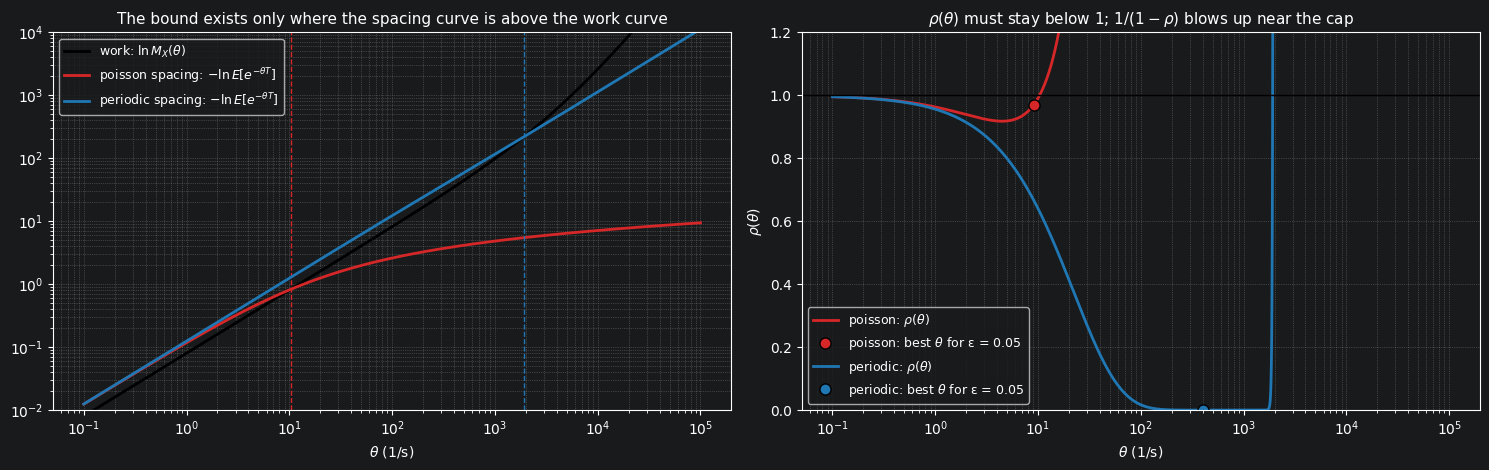

| process | cap $\theta^*$ (dashed lines) | best $\theta$ for $\varepsilon$ | confidence term $\ln(1/\varepsilon)/\theta$ |
|---|---|---|---|
| poisson | 10.4/s | 9.1/s | 329 ms |
| periodic | 1921.2/s | 407.3/s | 7 ms |

In [27]:
def theta_cap(process, rate=arrival_rate):
    # largest theta on the grid with rho(theta) < 1
    return theta_grid[np.argmax(log_mgf_execution() + log_gap_mgf(process, rate) >= 0)]


fig, (ax_rate, ax_rho) = plt.subplots(1, 2, figsize=(15, 4.8))
log_mx = log_mgf_execution()
ax_rate.loglog(theta_grid, log_mx, color="black", linewidth=2, label=r"work: $\ln M_X(\theta)$")
theta_star, theta_opt = {}, {}
for process in processes:
    log_rho = log_mx + log_gap_mgf(process)
    theta_star[process] = theta_cap(process)
    theta_opt[process] = snc_bound(process, epsilon)[1]

    ax_rate.loglog(theta_grid, -log_gap_mgf(process), color=colors[process], linewidth=2, label=rf"{process} spacing: $-\ln E[e^{{-\theta T}}]$")
    ax_rate.axvline(theta_star[process], color=colors[process], linestyle="--", linewidth=1)
    ax_rho.semilogx(theta_grid, np.exp(np.minimum(log_rho, 1)), color=colors[process], linewidth=2, label=rf"{process}: $\rho(\theta)$")
    ax_rho.plot(theta_opt[process], np.exp(log_rho[np.searchsorted(theta_grid, theta_opt[process])]), "o",
                color=colors[process], markersize=8, markeredgecolor="black", label=rf"{process}: best $\theta$ for ε = {epsilon:g}")
ax_rate.set_xlabel(r"$\theta$ (1/s)")
ax_rate.set_title("The bound exists only where the spacing curve is above the work curve", fontsize=11)
ax_rate.set_ylim(1e-2, 1e4)
ax_rate.legend(fontsize=9)
ax_rate.grid(True, which="both", linestyle=":", alpha=0.5)

ax_rho.axhline(1, color="black", linewidth=1)
ax_rho.set_ylim(0, 1.2)
ax_rho.set_xlabel(r"$\theta$ (1/s)")
ax_rho.set_ylabel(r"$\rho(\theta)$")
ax_rho.set_title(r"$\rho(\theta)$ must stay below 1; $1/(1-\rho)$ blows up near the cap", fontsize=11)
ax_rho.legend(fontsize=9)
ax_rho.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

display(Markdown(
    "| process | cap $\\theta^*$ (dashed lines) | best $\\theta$ for $\\varepsilon$ | confidence term $\\ln(1/\\varepsilon)/\\theta$ |\n|---|---|---|---|\n"
    + "\n".join(f"| {process} | {theta_star[process]:.1f}/s | {theta_opt[process]:.1f}/s | {ms(np.log(1 / epsilon) / theta_opt[process])} |"
                for process in processes)))

**Why the curves in Section 4 are parallel, and why the gap is still so large.** For Poisson, both the true tail and
the bound fall at (almost) the same rate $\theta^*$, so they are parallel lines on the log plot. The distance between
them is set by where each line *starts*:

- The true tail starts low: only the items that wait can have a long latency, and they are a minority (Section 3).
- The bound starts at $M_X(\theta)/(1-\rho(\theta)) \ge 1$: it does not know that most items don't wait. It
  effectively assumes every item is at the start of a burst.

From its higher starting level, the bound needs a longer stretch of $d$ to fall to $\varepsilon$ at the same slope.
The optimizer can't fix this: pushing $\theta$ up to $\theta^*$ makes $1/(1-\rho)$ explode, and pulling it down
flattens the slope. It settles at a compromise just below $\theta^*$ (right plot).

With periodic arrivals the cap is very large, the optimizer can pick a large $\theta$, and both the queue term and the
confidence term shrink. What is left is the Gaussian Chernoff bound $\mu + \sigma\sqrt{2\ln(1/\varepsilon)}$, which is
close to the true quantile $\mu + z_{1-\varepsilon}\sigma$ because $\sigma$ is small compared to $\mu$.

## 6. What the Bound Pays For

The three terms of $d(\varepsilon)$ at the best $\theta$, next to the true p95 split into the mean execution time
$\mu$ and everything above it. For Poisson, the part above $\mu$ is mostly waiting. For periodic, nobody waits, and it
is just the execution-time noise.

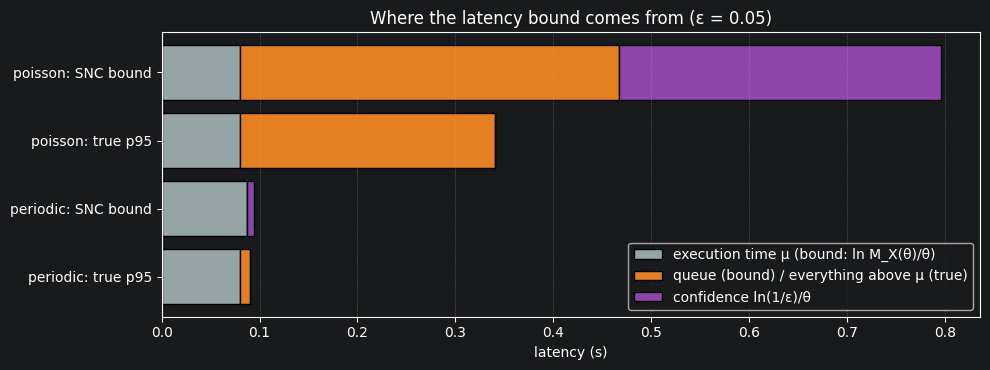

For Poisson, the bound's queue term is 387 ms, while the true p95 lies 261 ms above $\mu$; the confidence term adds 329 ms on top. Both are divided by a $\theta$ that is capped at 10.4/s. For periodic arrivals, the same two terms are 0 ms and 7 ms.

In [28]:
terms = {}
for process in processes:
    bound, theta = snc_bound(process, epsilon)
    i = np.searchsorted(theta_grid, theta)
    terms[process] = {"execution": log_mx[i] / theta,
                      "queue": (log_latency_moment(process)[i] - log_mx[i]) / theta,
                      "confidence": np.log(1 / epsilon) / theta,
                      "bound": bound}

rows = []
for process in processes:
    t = terms[process]
    rows.append((f"{process}: SNC bound", [t["execution"], t["queue"], t["confidence"]]))
    rows.append((f"{process}: true p95", [mu, decomposition[process]["true"] - mu, 0.0]))

fig, ax = plt.subplots(figsize=(10, 3.8))
labels = [label for label, _ in rows][::-1]
parts = np.array([values for _, values in rows])[::-1]
left = np.zeros(len(rows))
for k, (name, color) in enumerate(zip(["execution time μ (bound: ln M_X(θ)/θ)", "queue (bound) / everything above μ (true)",
                                       "confidence ln(1/ε)/θ"], ["#95a5a6", "#e67e22", "#8e44ad"])):
    ax.barh(labels, parts[:, k], left=left, color=color, edgecolor="black", label=name)
    left += parts[:, k]
ax.set_xlabel("latency (s)")
ax.set_title(f"Where the latency bound comes from (ε = {epsilon:g})")
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

p = terms["poisson"]
display(Markdown(
    f"For Poisson, the bound's queue term is {ms(p['queue'])}, while the true p95 lies {ms(decomposition['poisson']['true'] - mu)} "
    f"above $\\mu$; the confidence term adds {ms(p['confidence'])} on top. Both are divided by a $\\theta$ that is capped "
    f"at {theta_star['poisson']:.1f}/s. For periodic arrivals, the same two terms are {ms(terms['periodic']['queue'])} and "
    f"{ms(terms['periodic']['confidence'])}."))

## 7. Dependence on $\varepsilon$ and on the Load

- **$\varepsilon$:** for Poisson, the bound and the truth are parallel lines, so the gap between them is a roughly
  *constant* number of milliseconds. As $\varepsilon$ gets smaller, the latency itself grows, so the *ratio* shrinks,
  but only slowly.
- **Load:** two effects compete. At low load few items wait, but $\theta$ is still capped as long as bursts are
  possible at all, so the confidence term stays large. At high load the cap $\theta^*$ drops towards zero and the
  queue term grows. Periodic arrivals are unaffected as long as the gaps stay longer than one execution time.

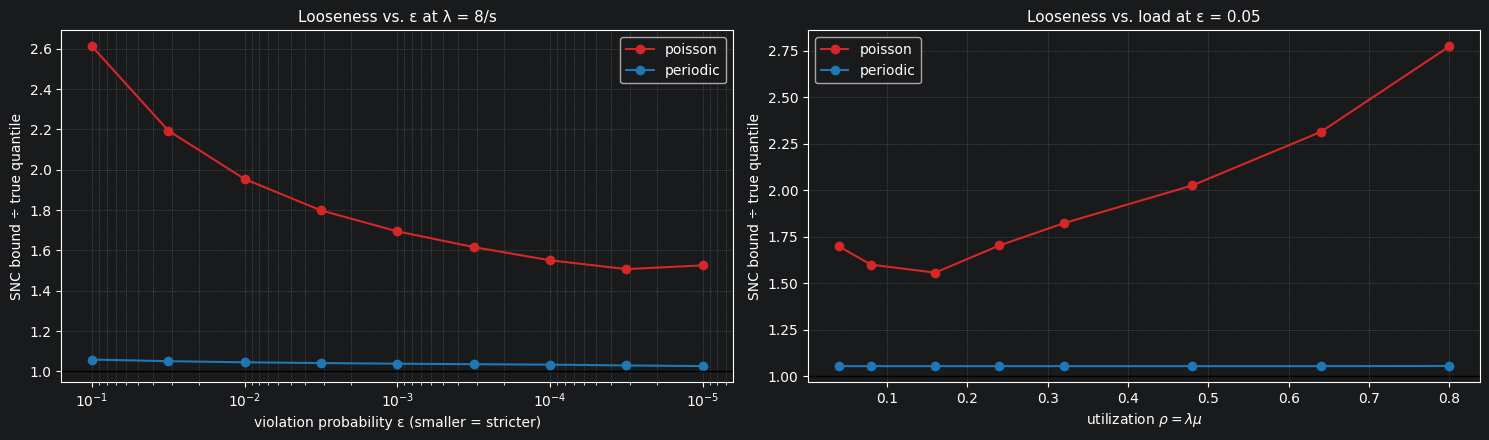

- **ε:** the Poisson ratio goes from 2.61× at ε = 1e-01 to 1.53× at ε = 1e-05; the periodic ratio stays between 1.03× and 1.06×.
- **Load:** the Poisson ratio is 1.70× at the lowest utilization (4%), 1.56× at its lowest (16%) and 2.77× at the highest (80%). The cap is $\theta^*$ = 59.0/s at the lowest load and 5.4/s at the highest. The periodic ratio stays 1.05×.

In [29]:
epsilons = np.logspace(-1, -5, 9)
rates = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0])   # items/s; utilization = rate * mu
ratio_by_eps, ratio_by_load = {}, {}

fig, (ax_eps, ax_load) = plt.subplots(1, 2, figsize=(15, 4.5))
for process in processes:
    samples, _ = simulate_latency(process, 2_000_000, np.random.default_rng(4))
    ratio_by_eps[process] = np.array([snc_bound(process, eps)[0] / np.quantile(samples, 1 - eps) for eps in epsilons])
    ax_eps.semilogx(epsilons, ratio_by_eps[process], "o-", color=colors[process], label=process)

    ratios = []
    for rate in rates:
        samples, _ = simulate_latency(process, 400_000, np.random.default_rng(5), rate=rate)
        ratios.append(snc_bound(process, epsilon, rate)[0] / np.quantile(samples, 1 - epsilon))
    ratio_by_load[process] = np.array(ratios)
    ax_load.plot(rates * mu, ratio_by_load[process], "o-", color=colors[process], label=process)

ax_eps.invert_xaxis()
ax_eps.set_xlabel("violation probability ε (smaller = stricter)")
ax_eps.set_title(f"Looseness vs. ε at λ = {arrival_rate:g}/s", fontsize=11)
ax_load.set_xlabel(r"utilization $\rho = \lambda\mu$")
ax_load.set_title(f"Looseness vs. load at ε = {epsilon:g}", fontsize=11)
for ax in (ax_eps, ax_load):
    ax.axhline(1, color="black", linewidth=1)
    ax.set_ylabel("SNC bound ÷ true quantile")
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

pe, pl = ratio_by_eps["poisson"], ratio_by_load["poisson"]
display(Markdown(
    f"- **ε:** the Poisson ratio goes from {pe[0]:.2f}× at ε = {epsilons[0]:.0e} to {pe[-1]:.2f}× at ε = {epsilons[-1]:.0e}; "
    f"the periodic ratio stays {span(ratio_by_eps['periodic'], lambda r: f'{r:.2f}×')}.\n"
    f"- **Load:** the Poisson ratio is {pl[0]:.2f}× at the lowest utilization ({rates[0] * mu:.0%}), "
    f"{pl.min():.2f}× at its lowest ({rates[np.argmin(pl)] * mu:.0%}) and {pl[-1]:.2f}× at the highest ({rates[-1] * mu:.0%}). "
    f"The cap is $\\theta^*$ = {theta_cap('poisson', rates[0]):.1f}/s at the lowest load and {theta_cap('poisson', rates[-1]):.1f}/s at the highest. "
    f"The periodic ratio stays {span(ratio_by_load['periodic'], lambda r: f'{r:.2f}×')}."))

## 8. Why It Gets Worse Along a Chain

In `method_v2`, every node bound assumes the *external* arrival process. For the first service that's correct. For
the second, it's not: s2 receives s1's **departures**, and s1 can't release two items closer together than about one
of its execution times. The bursts of the Poisson input are smoothed out by s1. Since s2's mean execution time is
shorter than s1's, s2 almost never queues.

The node bound for s2 still assumes Poisson arrivals, so it pays the whole Section 5 penalty a second time, for a
queue that barely exists. The same happens at every further node, which is why the PPG's looseness grows with the
chain depth in `method_v2` Section 9. With periodic arrivals there is nothing to smooth and nothing to over-count.

In [30]:
mu_2, sigma_2 = 0.072, 0.001   # execution time of s2 in method_v2 (s)
rng = np.random.default_rng(6)
n_items = 400_000
arrivals = np.cumsum(sample_gaps("poisson", n_items, rng))


def fifo(entering, execution):
    leaving = np.empty_like(entering)
    previous = 0.0
    for i in range(len(entering)):
        previous = max(entering[i], previous) + execution[i]
        leaving[i] = previous
    return leaving


s1_leaving = fifo(arrivals, np.maximum(rng.normal(mu, sigma, n_items), 0))
s2_in_chain = fifo(s1_leaving, np.maximum(rng.normal(mu_2, sigma_2, n_items), 0)) - s1_leaving
s2_poisson_fed = fifo(arrivals, np.maximum(rng.normal(mu_2, sigma_2, n_items), 0)) - arrivals

display(Markdown(
    f"| | into s2 behind s1 (real) | into s2 as Poisson (what the bound assumes) |\n|---|---|---|\n"
    f"| 1st percentile of the gaps between arrivals | {ms(np.quantile(np.diff(s1_leaving), 0.01))} | {ms(np.quantile(np.diff(arrivals), 0.01))} |\n"
    f"| p95 latency of s2 | {ms(np.quantile(s2_in_chain, 1 - epsilon))} | {ms(np.quantile(s2_poisson_fed, 1 - epsilon))} |"))

| | into s2 behind s1 (real) | into s2 as Poisson (what the bound assumes) |
|---|---|---|
| 1st percentile of the gaps between arrivals | 67 ms | 1 ms |
| p95 latency of s2 | 74 ms | 259 ms |

## Summary

- **Poisson arrivals come in bursts.** Short gaps are the most likely gaps, so items regularly arrive almost
  together. That makes the true latency tail *exponential* with a slow decay rate $\theta^*$.
- **An SNC bound can use $\theta$ only up to that decay rate**, because $\rho(\theta)$ must stay below 1. The bound pays
  $\ln(1/\varepsilon)/\theta$ for its confidence and $-\ln(1-\rho(\theta))/\theta$ for the queue, and with a small
  $\theta$ both are large.
- **The bound doesn't know that most items don't wait.** It runs parallel to the true tail but starts from
  probability 1 instead of the share of items that wait. That shift is the looseness. The union bound over queue
  lengths is not the problem.
- **Periodic arrivals** don't limit $\theta$, so the queue and confidence terms vanish and the bound is essentially the
  Gaussian bound on the execution time.
- **In a chain**, every node bound pays the penalty again, even though only the first node sees bursty arrivals.

The key numbers for the current parameters are in the table below.

**Levers, if the bound has to be tighter under Poisson arrivals:**
- Account for the idle share. Martingale-based SNC bounds carry a prefactor below 1 that reflects that most
  items don't wait, and they are much tighter for exactly this reason.
- Use network service curves for the chain, so the burst is paid only once rather than once per node.
- Report stricter targets (smaller $\varepsilon$), where the constant gap is a smaller share of the latency.

In [31]:
display(Markdown(
    f"| | Poisson | periodic |\n|---|---|---|\n"
    f"| share of items that wait | {wait_share['poisson']:.1%} | {wait_share['periodic']:.1%} |\n"
    f"| cap $\\theta^*$ | {theta_star['poisson']:.1f}/s | {theta_star['periodic']:.1f}/s |\n"
    f"| true p95 latency | {ms(decomposition['poisson']['true'])} | {ms(decomposition['periodic']['true'])} |\n"
    f"| SNC bound | {ms(decomposition['poisson']['snc'])} | {ms(decomposition['periodic']['snc'])} |\n"
    f"| bound ÷ true | {decomposition['poisson']['snc'] / decomposition['poisson']['true']:.2f}× | "
    f"{decomposition['periodic']['snc'] / decomposition['periodic']['true']:.2f}× |\n"
    f"| confidence term $\\ln(1/\\varepsilon)/\\theta$ | {ms(terms['poisson']['confidence'])} | {ms(terms['periodic']['confidence'])} |\n"
    f"| queue term $-\\ln(1-\\rho(\\theta))/\\theta$ | {ms(terms['poisson']['queue'])} | {ms(terms['periodic']['queue'])} |"))

| | Poisson | periodic |
|---|---|---|
| share of items that wait | 64.1% | 0.0% |
| cap $\theta^*$ | 10.4/s | 1921.2/s |
| true p95 latency | 341 ms | 90 ms |
| SNC bound | 796 ms | 95 ms |
| bound ÷ true | 2.33× | 1.05× |
| confidence term $\ln(1/\varepsilon)/\theta$ | 329 ms | 7 ms |
| queue term $-\ln(1-\rho(\theta))/\theta$ | 387 ms | 0 ms |